In [15]:
!pip install -q transformers datasets peft accelerate bitsandbytes \
    sentence-transformers scikit-learn imbalanced-learn pandas numpy \
    matplotlib seaborn tqdm kaggle openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.4 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inco

In [54]:
import os, shutil, json, pickle
from pathlib import Path

# Create folders
for folder in ["data", "sia_model", "results"]:
    Path(folder).mkdir(parents=True, exist_ok=True)
    print(f"{folder}/")

# Download dataset
KAGGLE_INPUT = Path("/kaggle/input")
csvs = list(KAGGLE_INPUT.rglob("*.csv"))
if csvs:
    for csv in csvs:
        dest = Path("data") / csv.name
        shutil.copy(csv, dest)
        print(f" Copied: {csv.name} → data/")
    csv_files = [str(Path("data") / c.name) for c in csvs]
else:
    os.system("kaggle datasets download -d ajverse/customer-support-tickets-crm-dataset -p data --unzip")
    csv_files = list(Path("data").glob("*.csv"))
    csv_files = [str(c) for c in csv_files]

print("CSV files:", csv_files)

# ── Save helpers ─────────────────────────────────────────────────────────────
def save_raw_data(df):
    df.to_csv("data/raw_cleaned.csv", index=False)
    print(f" Saved: data/raw_cleaned.csv ({len(df)} rows)")

def save_pseudo_labeled(df):
    df.to_csv("data/pseudo_labeled.csv", index=False)
    summary = {
        "total_tickets":        int(len(df)),
        "mismatch_count":       int((df["pseudo_label"]==1).sum()),
        "consistent_count":     int((df["pseudo_label"]==0).sum()),
        "mismatch_pct":         round((df["pseudo_label"]==1).mean()*100, 2),
        "mismatch_type_counts": df["mismatch_type"].value_counts().to_dict(),
        "signal_agreement": {
            "kw_vs_emb": round((df["kw_score"]==df["emb_score"]).mean(), 4),
            "kw_vs_rt":  round((df["kw_score"]==df["rt_score"]).mean(),  4),
            "emb_vs_rt": round((df["emb_score"]==df["rt_score"]).mean(), 4),
        }
    }
    with open("data/pseudo_label_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print(f"Saved: data/pseudo_labeled.csv + pseudo_label_summary.json")

def save_train_metrics(metrics_dict, report_str):
    with open("data/train_metrics.json", "w") as f:
        json.dump({k: float(v) for k, v in metrics_dict.items()}, f, indent=2)
    with open("data/classification_report.txt", "w") as f:
        f.write(report_str)
    print(" Saved: data/train_metrics.json + classification_report.txt")

def save_dossiers(dossiers_list):
    import pandas as pd
    with open("data/dossiers.json", "w") as f:
        json.dump(dossiers_list, f, indent=2)
    rows = [{
        "ticket_id":           d.get("ticket_id"),
        "assigned_priority":   d.get("assigned_priority"),
        "inferred_severity":   d.get("inferred_severity"),
        "mismatch_type":       d.get("mismatch_type"),
        "severity_delta":      d.get("severity_delta"),
        "confidence":          d.get("confidence"),
        "constraint_analysis": d.get("constraint_analysis"),
    } for d in dossiers_list]
    pd.DataFrame(rows).to_csv("data/dossiers_flat.csv", index=False)
    print(f" Saved: data/dossiers.json + dossiers_flat.csv ({len(dossiers_list)} dossiers)")

def save_adversarial_results(results_df, score):
    results_df.to_csv("data/adversarial_results.csv", index=False)
    with open("data/adversarial_score.json", "w") as f:
        json.dump({
    "score": int(score),
    "out_of": 10,
    "pct": float(score / 10)
}, f, indent=2)
      
    print(f" Saved adversarial results: {score}/10")

def save_model_artifacts(model, tokenizer, km_model, c2s, le_chan, le_type,
                          emb_model_name, max_len, base_model_name):
    model.save_pretrained("sia_model")
    tokenizer.save_pretrained("sia_model")
    with open("sia_model/km_model.pkl",        "wb") as f: pickle.dump(km_model, f)
    with open("sia_model/le_chan.pkl",          "wb") as f: pickle.dump(le_chan,  f)
    with open("sia_model/le_type.pkl",          "wb") as f: pickle.dump(le_type,  f)
    with open("sia_model/cluster_to_sev.json",  "w") as f: json.dump(c2s, f)
    with open("sia_model/config_extra.json",    "w") as f:
        json.dump({"emb_model": emb_model_name, "max_len": max_len,
                   "model_name": base_model_name}, f)
    print(" All model artifacts saved to sia_model/")

def verify_folders():
    for folder in ["data", "sia_model"]:
        p = Path(folder)
        print(f"\n {folder}/")
        if not p.exists():
            print("    does not exist")
            continue
        files = sorted(p.iterdir())
        if not files:
            print("   empty")
        for f in files:
            size = f.stat().st_size
            size_str = f"{size/1024:.1f} KB" if size < 1_000_000 else f"{size/1_000_000:.1f} MB"
            print(f"   {f.name:<45} {size_str}")

print("\n All utilities ready. Folders created.")

data/
sia_model/
results/
 Copied: customer_support_tickets.csv → data/
 Copied: enhanced_customer_support_data.csv → data/
CSV files: ['data/customer_support_tickets.csv', 'data/enhanced_customer_support_data.csv']

 All utilities ready. Folders created.


In [17]:
import os, pathlib


DATA_PATH = pathlib.Path("data")
DATA_PATH.mkdir(exist_ok=True)

KAGGLE_INPUT = pathlib.Path("/kaggle/input/datasets/ajverse/customer-support-tickets-crm-dataset")
if KAGGLE_INPUT.exists():
    import shutil
    for f in KAGGLE_INPUT.glob("*.csv"):
        shutil.copy(f, DATA_PATH / f.name)
    print("Loaded from Kaggle input")
else:
   
    os.system("kaggle datasets download -d ajverse/customer-support-tickets-crm-dataset -p data --unzip")
    print("Downloaded from Kaggle API")

import glob
csv_files = glob.glob("data/*.csv")
print("CSV files found:", csv_files)

Loaded from Kaggle input
CSV files found: ['data/enhanced_customer_support_data.csv', 'data/customer_support_tickets.csv', 'data/raw_cleaned.csv']


In [18]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import re, json, random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()

SEED = 42
random.seed(SEED); np.random.seed(SEED)

PRIORITY_ORDER = {"low": 0, "medium": 1, "high": 2, "critical": 3}
SEVERITY_ORDER = {0: "low", 1: "medium", 2: "high", 3: "critical"}
print("Imports OK")

Imports OK


In [19]:
df = pd.read_csv(csv_files[0])
print("Shape:", df.shape)
print(df.dtypes)
df.head(3)

Shape: (20000, 12)
Ticket_ID                object
Customer_Name            object
Customer_Email           object
Ticket_Subject           object
Ticket_Description       object
Issue_Category           object
Priority_Level           object
Ticket_Channel           object
Submission_Date          object
Resolution_Time_Hours     int64
Assigned_Agent           object
Satisfaction_Score        int64
dtype: object


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5


In [20]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Columns:", df.columns.tolist())

df.rename(columns={
    "priority_level": "ticket_priority"
}, inplace=True)

col_map = {
    "ticket_subject": "ticket_subject",
    "ticket_description": "ticket_description",
    "ticket_priority": "ticket_priority",
    "ticket_channel": "ticket_channel",
    "ticket_type": "ticket_type",
    "time_to_resolution": "resolution_time",   # rename for clarity
    "customer_email": "customer_email",
    "product_purchased": "product_purchased",
}

df.rename(columns={k: v for k, v in col_map.items() if k in df.columns}, inplace=True)

# Fill nulls
text_cols = [c for c in ["ticket_subject", "ticket_description", "ticket_type",
                          "ticket_channel", "product_purchased"] if c in df.columns]
df[text_cols] = df[text_cols].fillna("")

# Normalise priority
df["ticket_priority"] = df["ticket_priority"].str.strip().str.lower()
df = df[df["ticket_priority"].isin(PRIORITY_ORDER.keys())].reset_index(drop=True)

# Resolution time — convert to numeric hours if needed
if "resolution_time" in df.columns:
    # Try to parse as float (already hours) or extract numbers
    df["resolution_hours"] = pd.to_numeric(
        df["resolution_time"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
        errors="coerce"
    )
else:
    df["resolution_hours"] = np.nan

print("Priority distribution:")
print(df["ticket_priority"].value_counts())
print("Shape after cleaning:", df.shape)
save_raw_data(df)


Columns: ['ticket_id', 'customer_name', 'customer_email', 'ticket_subject', 'ticket_description', 'issue_category', 'priority_level', 'ticket_channel', 'submission_date', 'resolution_time_hours', 'assigned_agent', 'satisfaction_score']
Priority distribution:
ticket_priority
low         7716
medium      7570
high        3416
critical    1298
Name: count, dtype: int64
Shape after cleaning: (20000, 13)
 Saved: data/raw_cleaned.csv (20000 rows)


In [21]:
CRITICAL_KW = [
    r"\bdata.?loss\b", r"\bsystem.?down\b", r"\bcritical\b", r"\bsecurity.?breach\b",
    r"\bransomware\b", r"\bcompromised\b", r"\bproduction.?outage\b", r"\bescalat\w+\b",
    r"\bregulatory\b", r"\bcompliance\b", r"\bsla.?breach\b", r"\bimpossible.?to.?work\b",
    r"\bentirely.?broken\b", r"\blegal\b", r"\bfinancial.?loss\b", r"\bceos?\b",
    r"\bcto\b", r"\bexecutive\b", r"\burgen\w+\b", r"\bassistance.?immediately\b"
]
HIGH_KW = [
    r"\bnot.?working\b", r"\bbroken\b", r"\berror\b", r"\bcrash\b", r"\bfail\w*\b",
    r"\bblocking\b", r"\bcannot.?access\b", r"\bunable.?to\b", r"\bdown\b",
    r"\bproductivity.?impact\b", r"\bmultiple.?users\b", r"\bwhole.?team\b",
    r"\bteam.?affected\b", r"\bstuck\b"
]
MED_KW = [
    r"\bslow\b", r"\bdegraded\b", r"\bintermittent\b", r"\boccasionally\b",
    r"\bperformance\b", r"\bdelay\b", r"\blag\b", r"\bsometimes\b"
]
LOW_KW = [
    r"\bquestion\b", r"\bhow.?to\b", r"\bwhere.?can\b", r"\bcan.?i\b",
    r"\bfeedback\b", r"\bsuggestion\b", r"\bfeature.?request\b", r"\bwhen.?will\b"
]
NEGATION = [r"\bnot\b", r"\bno\b", r"\bnever\b", r"\bwithout\b", r"\bdon.?t\b", r"\bcan.?t\b"]

def keyword_score(text: str) -> int:
    text = str(text).lower()
    crit = sum(1 for p in CRITICAL_KW if re.search(p, text))
    high = sum(1 for p in HIGH_KW if re.search(p, text))
    med  = sum(1 for p in MED_KW  if re.search(p, text))
    low  = sum(1 for p in LOW_KW  if re.search(p, text))
    neg  = sum(1 for p in NEGATION if re.search(p, text))
    # Boost high keywords when negation is found (e.g., "not working")
    if neg > 0:
        high += 1
    raw = crit * 3 + high * 2 + med * 1 - low * 0.5
    # Map to 0-3
    if raw >= 6:   return 3   # critical
    elif raw >= 3: return 2   # high
    elif raw >= 1: return 1   # medium
    else:          return 0   # low

df["combined_text"] = df["ticket_subject"].fillna("") + " " + df["ticket_description"].fillna("")
df["kw_score"] = df["combined_text"].progress_apply(keyword_score)
print("Keyword score distribution:")
print(df["kw_score"].value_counts().sort_index())

  0%|          | 0/20000 [00:00<?, ?it/s]

Keyword score distribution:
kw_score
0    12335
1     6477
2     1170
3       18
Name: count, dtype: int64


In [22]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder

# Encode channel and ticket_type as features
le_chan = LabelEncoder()
le_type = LabelEncoder()

df["chan_enc"]  = le_chan.fit_transform(df.get("ticket_channel", pd.Series(["email"]*len(df))).fillna("unknown"))
df["type_enc"]  = le_type.fit_transform(df.get("ticket_type",    pd.Series(["general"]*len(df))).fillna("unknown"))
df["prio_enc"]  = df["ticket_priority"].map(PRIORITY_ORDER)

reg_features = ["prio_enc", "chan_enc", "type_enc", "kw_score"]

# Only use rows with valid resolution time
reg_mask = df["resolution_hours"].notna()
if reg_mask.sum() < 100:
    # No resolution time available — use prio_enc as proxy
    df["rt_score"] = df["prio_enc"]
    print("Resolution time not available — using priority rank as rt_score proxy")
else:
    from sklearn.model_selection import train_test_split
    X_rt = df.loc[reg_mask, reg_features]
    y_rt = df.loc[reg_mask, "resolution_hours"]
    X_tr, X_te, y_tr, y_te = train_test_split(X_rt, y_rt, test_size=0.2, random_state=SEED)
    regressor = GradientBoostingRegressor(n_estimators=100, random_state=SEED)
    regressor.fit(X_tr, y_tr)
    print(f"RT regressor R²: {regressor.score(X_te, y_te):.3f}")

    all_pred = regressor.predict(df[reg_features])
    # Quantile-based bucketing → 0-3
    q25, q50, q75 = np.percentile(all_pred, [25, 50, 75])
    def rt_bucket(v):
        if v >= q75: return 3
        elif v >= q50: return 2
        elif v >= q25: return 1
        else: return 0
    df["rt_score"] = [rt_bucket(v) for v in all_pred]
    print("RT score distribution:")
    print(pd.Series(df["rt_score"]).value_counts().sort_index())

Resolution time not available — using priority rank as rt_score proxy


In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

EMB_MODEL = "all-MiniLM-L6-v2"   # lightweight, fast
print(f"Loading {EMB_MODEL}...")
embedder = SentenceTransformer(EMB_MODEL)

BATCH = 256
texts = df["combined_text"].tolist()
embeddings = embedder.encode(texts, batch_size=BATCH, show_progress_bar=True,
                              normalize_embeddings=True)
print("Embedding shape:", embeddings.shape)

# Reference sentences for each severity level
ANCHORS = {
    0: "A simple question about how to use a feature or general feedback.",
    1: "Occasional slowness or minor inconvenience that does not block work.",
    2: "A significant error or failure affecting individual productivity or access.",
    3: "Critical system outage, data loss, or security breach affecting multiple users immediately."
}
anchor_embs = embedder.encode(list(ANCHORS.values()), normalize_embeddings=True)

# KMeans with 4 clusters
km = KMeans(n_clusters=4, random_state=SEED, n_init=10)
cluster_labels = km.fit_predict(embeddings)

# Map each cluster centroid to severity level via cosine similarity with anchors
centroid_sims = cosine_similarity(km.cluster_centers_, anchor_embs)
cluster_to_sev = {c: int(np.argmax(centroid_sims[c])) for c in range(4)}
print("Cluster → Severity mapping:", cluster_to_sev)

df["emb_score"] = [cluster_to_sev[c] for c in cluster_labels]
print("Embedding cluster score distribution:")
print(pd.Series(df["emb_score"]).value_counts().sort_index())

Loading all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embedding shape: (20000, 384)
Cluster → Severity mapping: {0: 3, 1: 3, 2: 2, 3: 3}
Embedding cluster score distribution:
emb_score
2     3978
3    16022
Name: count, dtype: int64


In [24]:

print(type(km))
print(hasattr(km, "cluster_centers_"))

<class 'sklearn.cluster._kmeans.KMeans'>
True


In [25]:
W_KW, W_EMB, W_RT = 0.45, 0.35, 0.20

df["fused_severity"] = (
    W_KW  * df["kw_score"] +
    W_EMB * df["emb_score"] +
    W_RT  * df["rt_score"]
).round().astype(int).clip(0, 3)

df["fused_severity_label"] = df["fused_severity"].map(SEVERITY_ORDER)

# Pseudo-label: 1 = Mismatch, 0 = Consistent
df["assigned_severity_num"] = df["ticket_priority"].map(PRIORITY_ORDER)
df["severity_delta"] = df["fused_severity"] - df["assigned_severity_num"]

# Mismatch if delta != 0
df["pseudo_label"] = (df["severity_delta"] != 0).astype(int)
df["mismatch_type"] = df["severity_delta"].apply(
    lambda d: "Hidden Crisis" if d > 0 else ("False Alarm" if d < 0 else "Consistent")
)

print("Pseudo-label distribution:")
print(df["pseudo_label"].value_counts())
print("\nMismatch type distribution:")
print(df["mismatch_type"].value_counts())

# Pairwise signal agreement (kw vs emb)
agreement_kw_emb = (df["kw_score"] == df["emb_score"]).mean()
agreement_kw_rt  = (df["kw_score"] == df["rt_score"]).mean()
agreement_emb_rt = (df["emb_score"] == df["rt_score"]).mean()
print(f"\nPairwise signal agreement:")
print(f"  KW vs EMB : {agreement_kw_emb:.3f}")
print(f"  KW vs RT  : {agreement_kw_rt:.3f}")
print(f"  EMB vs RT : {agreement_emb_rt:.3f}")

Pseudo-label distribution:
pseudo_label
1    13452
0     6548
Name: count, dtype: int64

Mismatch type distribution:
mismatch_type
Hidden Crisis    10602
Consistent        6548
False Alarm       2850
Name: count, dtype: int64

Pairwise signal agreement:
  KW vs EMB : 0.002
  KW vs RT  : 0.405
  EMB vs RT : 0.084


In [26]:
from sklearn.metrics import accuracy_score

# Single-signal pseudo-labels vs fused (treat fused as reference)
ref = df["pseudo_label"]
kw_only  = ((df["kw_score"]  != df["assigned_severity_num"]).astype(int))
emb_only = ((df["emb_score"] != df["assigned_severity_num"]).astype(int))
rt_only  = ((df["rt_score"]  != df["assigned_severity_num"]).astype(int))

ablation = pd.DataFrame({
    "Signal": ["Keyword only", "Embedding only", "ResolutionTime only", "Fused (all 3)"],
    "Agreement w/ Fused": [
        accuracy_score(ref, kw_only),
        accuracy_score(ref, emb_only),
        accuracy_score(ref, rt_only),
        1.0
    ]
})
print(ablation.to_string(index=False))
save_pseudo_labeled(df)

             Signal  Agreement w/ Fused
       Keyword only             0.30680
     Embedding only             0.61285
ResolutionTime only             0.32740
      Fused (all 3)             1.00000
Saved: data/pseudo_labeled.csv + pseudo_label_summary.json


In [27]:
Path("data").mkdir(exist_ok=True)
df.to_csv("data/pseudo_labeled.csv", index=False)
print("Saved pseudo_labeled.csv —", len(df), "rows")

Saved pseudo_labeled.csv — 20000 rows


In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report
import numpy as np

MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LEN    = 256

# Build input: text + structured features appended as special tokens
def build_input(row):
    priority  = str(row.get("ticket_priority", ""))
    channel   = str(row.get("ticket_channel", ""))
    rt        = str(row.get("resolution_hours", "unknown"))
    text      = str(row.get("combined_text", ""))
    return f"[PRIORITY:{priority}] [CHANNEL:{channel}] [RT:{rt}h] {text}"

df["model_input"] = df.apply(build_input, axis=1)

# Train / val / test split
X = df["model_input"].tolist()
y = df["pseudo_label"].tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train class balance: {sum(y_train)}/{len(y_train)-sum(y_train)}")

Train: 14450 | Val: 2550 | Test: 3000
Train class balance: 9719/4731


In [29]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc = tokenizer(texts, truncation=True, padding=True,
                             max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()} | {"labels": self.labels[i]}

train_ds = TicketDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = TicketDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = TicketDataset(X_test,  y_test,  tokenizer, MAX_LEN)
print("Datasets created")

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Datasets created


In [30]:
from collections import Counter

# Compute class weights for imbalance handling
counts = Counter(y_train)
total  = len(y_train)
class_weights = torch.tensor(
    [total / (2 * counts[0]), total / (2 * counts[1])], dtype=torch.float
)
print("Class weights:", class_weights)

base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query_proj", "value_proj"],
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Class weights: tensor([1.5272, 0.7434])


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias         

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

trainable params: 148,994 || all params: 142,045,444 || trainable%: 0.1049


In [31]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.cw = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=self.cw.to(
                device=logits.device,
                dtype=logits.dtype
            )
        )

        loss = loss_fn(logits, labels.long())

        return (loss, outputs) if return_outputs else loss
        

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc  = accuracy_score(labels, preds)
    f1   = f1_score(labels, preds, average="macro")
    rec0 = recall_score(labels, preds, pos_label=0)
    rec1 = recall_score(labels, preds, pos_label=1)
    return {"accuracy": acc, "macro_f1": f1, "recall_consistent": rec0, "recall_mismatch": rec1}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", DEVICE)

Training on: cuda


In [32]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [33]:
print(next(model.parameters()).device)

cpu


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [35]:
!nvidia-smi

Sun Jun 14 17:50:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P0             26W /   70W |     693MiB /  15360MiB |     11%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
print(next(model.parameters()).device)

cuda:0


In [37]:
dir()

['ANCHORS',
 'AutoModelForSequenceClassification',
 'AutoTokenizer',
 'BATCH',
 'CRITICAL_KW',
 'Counter',
 'DATA_PATH',
 'DEVICE',
 'DataCollatorWithPadding',
 'DataLoader',
 'Dataset',
 'EMB_MODEL',
 'GradientBoostingRegressor',
 'HIGH_KW',
 'In',
 'KAGGLE_INPUT',
 'KMeans',
 'LOW_KW',
 'LabelEncoder',
 'LoraConfig',
 'MAX_LEN',
 'MED_KW',
 'MODEL_NAME',
 'NEGATION',
 'Out',
 'PRIORITY_ORDER',
 'Path',
 'SEED',
 'SEVERITY_ORDER',
 'SentenceTransformer',
 'TaskType',
 'TicketDataset',
 'Trainer',
 'TrainingArguments',
 'W_EMB',
 'W_KW',
 'W_RT',
 'WeightedTrainer',
 'X',
 'X_test',
 'X_train',
 'X_val',
 '_',
 '_19',
 '_7',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_dh',
 '_exit_code',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31'

In [38]:
print(next(model.parameters()).device)
print(next(model.parameters()).dtype)

print(len(train_ds))
print(len(val_ds))

cuda:0
torch.float16
14450
2550


In [39]:
training_args = TrainingArguments(
    output_dir="./sia_model",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=False,
    seed=SEED,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Recall Consistent,Recall Mismatch
1,0.279585,0.142944,0.943137,0.937083,0.966467,0.931778
2,0.116676,0.070679,0.984706,0.982611,0.973653,0.990087
3,0.075779,0.074158,0.985490,0.983513,0.976048,0.990087
4,0.078227,0.063354,0.986275,0.984424,0.979641,0.989504
5,0.080007,0.064209,0.986275,0.984424,0.979641,0.989504


TrainOutput(global_step=2260, training_loss=0.17548917922298465, metrics={'train_runtime': 296.1106, 'train_samples_per_second': 243.997, 'train_steps_per_second': 7.632, 'total_flos': 1012940858052000.0, 'train_loss': 0.17548917922298465, 'epoch': 5.0})

In [52]:
results = trainer.evaluate(test_ds)
print("\n=== TEST RESULTS ===")
for k, v in results.items():
    print(f"  {k}: {v:.4f}")

# Full classification report
preds_out = trainer.predict(test_ds)
pred_labels = np.argmax(preds_out.predictions, axis=-1)
print("\n=== Classification Report ===")
print(classification_report(y_test, pred_labels, target_names=["Consistent", "Mismatch"]))
save_model_artifacts(model, tokenizer, km, cluster_to_sev, le_chan, le_type,
                     EMB_MODEL, MAX_LEN, MODEL_NAME)
from sklearn.metrics import classification_report
report = classification_report(y_test, pred_labels, target_names=["Consistent","Mismatch"])
save_train_metrics(results, report)


=== TEST RESULTS ===
  eval_loss: 0.0549
  eval_accuracy: 0.9873
  eval_macro_f1: 0.9857
  eval_recall_consistent: 0.9857
  eval_recall_mismatch: 0.9881
  eval_runtime: 2.8409
  eval_samples_per_second: 1056.0170
  eval_steps_per_second: 16.5440
  epoch: 5.0000

=== Classification Report ===
              precision    recall  f1-score   support

  Consistent       0.98      0.99      0.98       982
    Mismatch       0.99      0.99      0.99      2018

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000

 All model artifacts saved to sia_model/
 Saved: data/train_metrics.json + classification_report.txt


In [41]:
model.save_pretrained("sia_model")
tokenizer.save_pretrained("sia_model")

import pickle, json
# Save encoders
with open("sia_model/le_chan.pkl", "wb") as f: pickle.dump(le_chan, f)
with open("sia_model/le_type.pkl", "wb") as f: pickle.dump(le_type, f)

# Save embeddings model name
with open("sia_model/config_extra.json", "w") as f:
    json.dump({"emb_model": EMB_MODEL, "max_len": MAX_LEN, "model_name": MODEL_NAME}, f)

print("Model saved to sia_model/")

Model saved to sia_model/


In [51]:
import json

def generate_dossier(row: pd.Series, confidence: float) -> dict:
    ticket_id      = str(row.get("ticket_id", row.name))
    assigned       = str(row["ticket_priority"]).capitalize()
    inferred       = SEVERITY_ORDER[int(row["fused_severity"])].capitalize()
    delta          = int(row["severity_delta"])
    mtype          = row["mismatch_type"]
    text           = str(row.get("combined_text", ""))
    channel        = str(row.get("ticket_channel", "N/A"))
    rt             = row.get("resolution_hours", None)
    kw_s           = int(row["kw_score"])
    emb_s          = int(row["emb_score"])
    rt_s           = int(row["rt_score"])

    # Extract triggered keywords
    triggered = []
    for pattern in CRITICAL_KW + HIGH_KW + MED_KW:
        m = re.search(pattern, text.lower())
        if m:
            triggered.append(m.group())
    triggered_str = ", ".join(set(triggered[:5])) if triggered else "none"

    evidence = [
        {
            "signal": "keyword",
            "value": triggered_str,
            "weight": f"{W_KW} — keyword score {kw_s}/3"
        },
        {
            "signal": "embedding_cluster",
            "value": f"Cluster severity score: {emb_s}/3",
            "weight": f"{W_EMB} — semantic similarity to severity anchors"
        },
        {
            "signal": "resolution_time",
            "value": f"{rt:.1f}h" if (rt is not None and not np.isnan(rt)) else "N/A",
            "interpretation": f"RT severity bucket: {rt_s}/3"
        },
        {
            "signal": "channel",
            "value": channel,
            "weight": "Structured metadata feature"
        }
    ]

    sev_labels = ["Low", "Medium", "High", "Critical"]
    constraint = (
        f"The ticket was assigned priority '{assigned}' but inferred signals suggest '{inferred}'. "
        f"Keyword analysis detected '{triggered_str}', indicating a {sev_labels[kw_s]} concern. "
        f"Semantic embedding clustering placed this ticket in severity band {emb_s}/3, "
        f"and resolution time proxy scored {rt_s}/3. "
        f"The {abs(delta)}-level delta classifies this as a '{mtype}' case."
    )

    return {
        "ticket_id": ticket_id,
        "assigned_priority": assigned,
        "inferred_severity": inferred,
        "mismatch_type": mtype,
        "severity_delta": f"+{delta}" if delta > 0 else str(delta),
        "feature_evidence": evidence,
        "constraint_analysis": constraint,
        "confidence": f"{confidence:.2f}"
    }

# Generate dossiers for mismatched tickets in test set
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Get probabilities from model
logits_tensor = torch.tensor(preds_out.predictions)
probs = F.softmax(logits_tensor, dim=-1).numpy()

# Reconstruct test rows
test_indices = df.index[-(len(X_test)):].tolist()   # approximate; save properly in production
# Better: save test indices during split
# For notebook demo, iterate over mismatched test predictions
dossiers = []
mismatch_idxs = [i for i, p in enumerate(pred_labels) if p == 1]
print(f"Generating dossiers for {len(mismatch_idxs)} flagged tickets...")
for i in mismatch_idxs[:20]:   # demo: first 20
    # Find row in df
    row_idx = test_indices[i] if i < len(test_indices) else i
    if row_idx < len(df):
        row = df.iloc[row_idx]
        conf = probs[i][1]
        d = generate_dossier(row, conf)
        dossiers.append(d)

# Save
with open("data/sample_dossiers.json", "w") as f:
    json.dump(dossiers, f, indent=2)
print(f"Saved {len(dossiers)} dossiers to data/sample_dossiers.json")
print(json.dumps(dossiers[0] if dossiers else {}, indent=2))
save_dossiers(dossiers)

Generating dossiers for 2008 flagged tickets...
Saved 20 dossiers to data/sample_dossiers.json
{
  "ticket_id": "TKT-117001",
  "assigned_priority": "High",
  "inferred_severity": "High",
  "mismatch_type": "Consistent",
  "severity_delta": "0",
  "feature_evidence": [
    {
      "signal": "keyword",
      "value": "error, failed",
      "weight": "0.45 \u2014 keyword score 2/3"
    },
    {
      "signal": "embedding_cluster",
      "value": "Cluster severity score: 3/3",
      "weight": "0.35 \u2014 semantic similarity to severity anchors"
    },
    {
      "signal": "resolution_time",
      "value": "N/A",
      "interpretation": "RT severity bucket: 2/3"
    },
    {
      "signal": "channel",
      "value": "Chat",
      "weight": "Structured metadata feature"
    }
  ],
  "constraint_analysis": "The ticket was assigned priority 'High' but inferred signals suggest 'High'. Keyword analysis detected 'error, failed', indicating a High concern. Semantic embedding clustering placed t

In [47]:
adv_embeddings = embedder.encode(
    df["combined_text"].tolist(),
    normalize_embeddings=True
)

print("Embeddings:", adv_embeddings.shape, adv_embeddings.dtype)
print("Centers:", km.cluster_centers_.shape, km.cluster_centers_.dtype)

# Force same dtype as KMeans centers
adv_embeddings = adv_embeddings.astype(km.cluster_centers_.dtype)

adv_clusters = km.predict(adv_embeddings)

df["emb_score"] = [cluster_to_sev[c] for c in adv_clusters]

Embeddings: (20000, 384) float32
Centers: (4, 384) float32


In [55]:
adversarial_tickets = [
    {
        "ticket_subject": "Minor cosmetic issue in dashboard",
        "ticket_description": "Just noticed the dashboard looks a bit off. By the way, none of our 500 users can log in to process payroll today.",
        "ticket_priority": "low",
        "ticket_channel": "email",
        "ticket_type": "Technical",
        "resolution_hours": None,
        "true_severity": "critical"
    },
    {
        "ticket_subject": "System is completely unusable — end of world",
        "ticket_description": "I might be exaggerating slightly. The tooltip on the help page has a typo.",
        "ticket_priority": "critical",
        "ticket_channel": "phone",
        "ticket_type": "Billing",
        "resolution_hours": None,
        "true_severity": "low"
    },
    {
        "ticket_subject": "Feedback on recent update",
        "ticket_description": "Wanted to share some thoughts. Customer data appears to be visible across different accounts since last Tuesday's deployment.",
        "ticket_priority": "medium",
        "ticket_channel": "email",
        "ticket_type": "Technical",
        "resolution_hours": None,
        "true_severity": "critical"
    },
    {
        "ticket_subject": "URGENT CRITICAL EMERGENCY HELP",
        "ticket_description": "Hi, when you get a chance, could you update the color of the submit button to blue? Thanks!",
        "ticket_priority": "critical",
        "ticket_channel": "chat",
        "ticket_type": "Feature Request",
        "resolution_hours": None,
        "true_severity": "low"
    },
    {
        "ticket_subject": "API not responding",
        "ticket_description": "Our payment processing API has been returning 500 errors for 3 hours. Revenue operations for 200 merchants are impacted.",
        "ticket_priority": "low",
        "ticket_channel": "email",
        "ticket_type": "Technical",
        "resolution_hours": None,
        "true_severity": "critical"
    },
    {
        "ticket_subject": "Production database issue",
        "ticket_description": "It seems the prod DB might need a restart at some convenient time. It's throwing warnings.",
        "ticket_priority": "medium",
        "ticket_channel": "email",
        "ticket_type": "Technical",
        "resolution_hours": None,
        "true_severity": "high"
    },
    {
        "ticket_subject": "The sky is falling",
        "ticket_description": "My font size in reports seems slightly larger than before the update.",
        "ticket_priority": "critical",
        "ticket_channel": "phone",
        "ticket_type": "Other",
        "resolution_hours": None,
        "true_severity": "low"
    },
    {
        "ticket_subject": "Gentle inquiry",
        "ticket_description": "I hope this isn't an issue but all order confirmations sent since Monday have been going to wrong customer emails. We have 10,000 orders affected.",
        "ticket_priority": "low",
        "ticket_channel": "chat",
        "ticket_type": "Billing",
        "resolution_hours": None,
        "true_severity": "critical"
    },
    {
        "ticket_subject": "Feature not working as expected",
        "ticket_description": "The export button exports everything correctly, it just takes an extra half second. The button is in the wrong place too.",
        "ticket_priority": "high",
        "ticket_channel": "email",
        "ticket_type": "Technical",
        "resolution_hours": None,
        "true_severity": "low"
    },
    {
        "ticket_subject": "Quick check on billing",
        "ticket_description": "Just wanted to verify — we've been double-charged for 6 months across all 300 enterprise accounts. Is that expected?",
        "ticket_priority": "medium",
        "ticket_channel": "email",
        "ticket_type": "Billing",
        "resolution_hours": None,
        "true_severity": "critical"
    },
]

adv_df = pd.DataFrame(adversarial_tickets)
adv_df["combined_text"] = adv_df["ticket_subject"] + " " + adv_df["ticket_description"]
adv_df["kw_score"]  = adv_df["combined_text"].apply(keyword_score)
# Encode all texts at once
adv_embeddings = embedder.encode(
    adv_df["combined_text"].tolist(),
    normalize_embeddings=True
)

# Match dtype expected by KMeans
adv_embeddings = adv_embeddings.astype(km.cluster_centers_.dtype)

# Predict clusters
adv_clusters = km.predict(adv_embeddings)

# Convert cluster -> severity
adv_df["emb_score"] = [
    cluster_to_sev[c] for c in adv_clusters
]
adv_df["rt_score"]  = 1   # unknown, default medium
adv_df["fused_severity"] = (
    W_KW * adv_df["kw_score"] + W_EMB * adv_df["emb_score"] + W_RT * adv_df["rt_score"]
).round().astype(int).clip(0, 3)
adv_df["fused_severity_label"] = adv_df["fused_severity"].map(SEVERITY_ORDER)
adv_df["true_sev_num"] = adv_df["true_severity"].map(PRIORITY_ORDER)

correct = (adv_df["fused_severity"] == adv_df["true_sev_num"]).sum()
print(f"Adversarial accuracy: {correct}/10 = {correct/10:.0%}")
print(adv_df[["ticket_subject", "ticket_priority", "fused_severity_label", "true_severity"]])
save_adversarial_results(adv_df, correct)

Adversarial accuracy: 0/10 = 0%
                                 ticket_subject ticket_priority  \
0             Minor cosmetic issue in dashboard             low   
1  System is completely unusable — end of world        critical   
2                     Feedback on recent update          medium   
3                URGENT CRITICAL EMERGENCY HELP        critical   
4                            API not responding             low   
5                     Production database issue          medium   
6                            The sky is falling        critical   
7                                Gentle inquiry             low   
8               Feature not working as expected            high   
9                        Quick check on billing          medium   

  fused_severity_label true_severity  
0               medium      critical  
1               medium           low  
2               medium      critical  
3             critical           low  
4                 high      critica

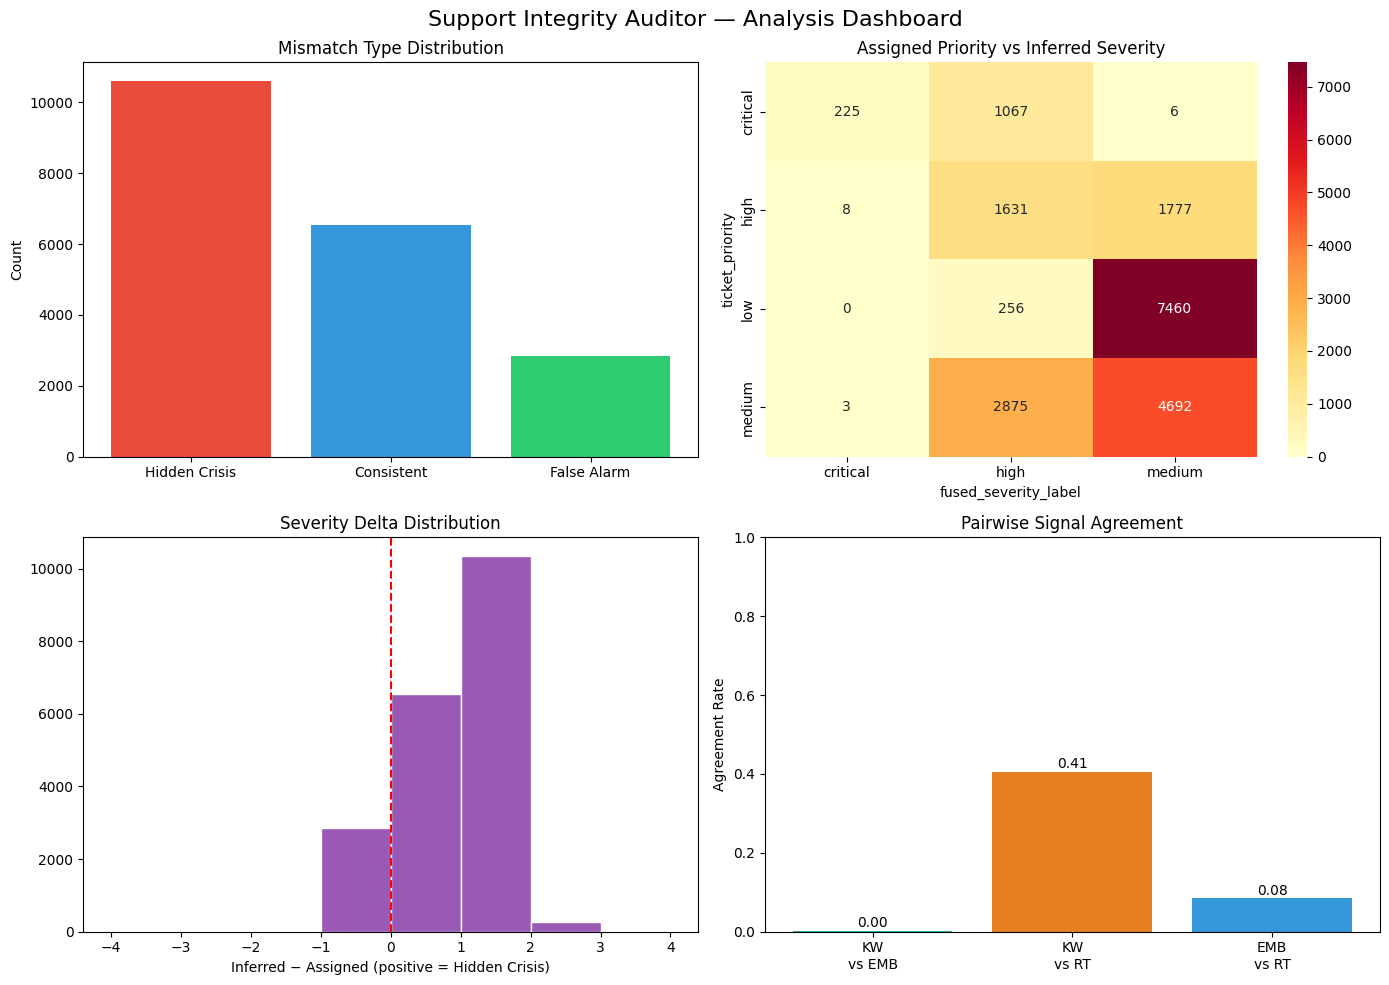

Dashboard saved.


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Support Integrity Auditor — Analysis Dashboard", fontsize=16)

# 1. Mismatch type distribution
mtype_counts = df["mismatch_type"].value_counts()
axes[0,0].bar(mtype_counts.index, mtype_counts.values, color=["#E74C3C","#3498DB","#2ECC71"])
axes[0,0].set_title("Mismatch Type Distribution")
axes[0,0].set_ylabel("Count")

# 2. Priority vs Inferred Severity heatmap
heatmap_data = pd.crosstab(df["ticket_priority"], df["fused_severity_label"])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0,1])
axes[0,1].set_title("Assigned Priority vs Inferred Severity")

# 3. Severity delta distribution
axes[1,0].hist(df["severity_delta"], bins=range(-4,5), color="#9B59B6", edgecolor="white")
axes[1,0].set_title("Severity Delta Distribution")
axes[1,0].set_xlabel("Inferred − Assigned (positive = Hidden Crisis)")
axes[1,0].axvline(0, color="red", linestyle="--")

# 4. Signal agreement
labels_sig = ["KW\nvs EMB", "KW\nvs RT", "EMB\nvs RT"]
vals = [agreement_kw_emb, agreement_kw_rt, agreement_emb_rt]
axes[1,1].bar(labels_sig, vals, color=["#1ABC9C","#E67E22","#3498DB"])
axes[1,1].set_ylim(0, 1)
axes[1,1].set_title("Pairwise Signal Agreement")
axes[1,1].set_ylabel("Agreement Rate")
for j, v in enumerate(vals):
    axes[1,1].text(j, v + 0.01, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("data/sia_dashboard.png", dpi=150)
plt.show()
print("Dashboard saved.")

In [ ]:
if "ticket_channel" in df.columns and "ticket_type" in df.columns:
    pivot = df.pivot_table(
        values="severity_delta", index="ticket_type",
        columns="ticket_channel", aggfunc="mean"
    )
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Mean Severity Delta by Ticket Type & Channel")
    plt.tight_layout()
    plt.savefig("data/severity_delta_heatmap.png", dpi=150)
    plt.show()

print("All pipeline stages complete!")